# AI Рекрутинговый Агент — Сравнение методов подбора

**АО Home Credit Bank (ДБ АО «ForteBank»)**

В этом ноутбуке сравниваются три метода подбора кандидатов, реализованных в рекрутинговом пайплайне:

| Метод | Описание | Преимущества | Недостатки |
|-------|----------|--------------|------------|
| **TF-IDF** | Лексическое косинусное сходство (sklearn `TfidfVectorizer`) | Быстро, детерминированно, не требует модели | Не понимает синонимы и семантические паrafraзы |
| **Семантика (BGE-M3)** | Косинусное сходство на плотных эмбеддингах `BAAI/bge-m3` | Понимает смысл на RU+EN, устойчив к перефразированию | Медленнее TF-IDF, требует загрузки модели (~1.5 ГБ) |
| **LLM (OpenAI gpt-4o-mini)** | Оценка через промпт с возвратом структурированного JSON | Лучшая точность, объяснения на русском, разбор сильных сторон и пробелов | Самый медленный (~1–3с на кандидата), платный |

В продакшне все три метода работают как **каскадная воронка**: TF-IDF → BGE-M3 → LLM, последовательно сужая пул кандидатов.

## Архитектура системы

```
Почтовый ящик (IMAP)        hh.kz
       │                      │
       ▼                      ▼
[Загрузка писем]       [Playwright-скрапер]
       │                      │
       ▼                      ▼
[docling: PDF → markdown]  [База вакансий (PostgreSQL)]
       │
       ▼
[OpenAI gpt-4o-mini: извлечение данных]
  → {имя, email, телефон, навыки, опыт, образование}
       │
       ▼
[База кандидатов (PostgreSQL)]
  - raw_text (markdown)  ← используется всеми тремя методами
  - embedding (1024-мер) ← вектор BGE-M3
       │
       ▼
[3-этапная воронка подбора]
  Этап 1: TF-IDF cosine ≥ 0.05   →  убирает явные несоответствия
  Этап 2: BGE-M3 semantic ≥ 0.35  →  убирает семантически нерелевантных
  Этап 3: OpenAI LLM top-K        →  глубокий анализ + объяснение
       │
       ▼
[FastAPI] → [Streamlit UI]
```

## Подготовка

Перед запуском ноутбука убедитесь, что стек запущен:

```bash
docker-compose up -d
```

Ноутбук обращается к FastAPI-бэкенду по адресу `http://localhost:8000` — локальная загрузка моделей и прямое подключение к БД не требуются.

In [28]:
import json
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

API_URL = "http://localhost:8000"

def api(path, params=None):
    r = requests.get(f"{API_URL}{path}", params=params, timeout=300)
    r.raise_for_status()
    return r.json()

health = api("/health")
print(f"Статус API  : {health['status']}")
print(f"Кандидатов  : {health['candidate_count']}")
print(f"Вакансий    : {health['vacancy_count']}")

Статус API  : ok
Кандидатов  : 12
Вакансий    : 39


## 1. Реальные данные — вакансии и кандидаты

In [29]:
vacancies = api("/vacancies/")
candidates = api("/candidates/")

print(f"Загружено {len(vacancies)} вакансий и {len(candidates)} кандидатов\n")
print("Вакансии:")
for v in vacancies:
    print(f"  [{v['id']}] {v['title']}")
print("\nКандидаты:")
for c in candidates:
    exp = f"{c['experience_years']:.1f} лет" if c.get("experience_years") is not None else "—"
    print(f"  [{c['id']}] {c['name'] or 'Неизвестно':<35} {exp}")

Загружено 39 вакансий и 12 кандидатов

Вакансии:
  [39] Главный специалист управления бизнес - информации
  [38] Главный менеджер по управлению эффективностью
  [37] Главный менеджер по аудиту информационных технологий
  [36] Начальник управления отчетности и методологии
  [35] Tech-юрист
  [34] Team Lead Oracle DBA
  [33] Главный аналитик в отдел риск аналитики и андеррайтинга
  [32] Главный аналитик в Отдел по аналитике качества портфеля
  [31] Менеджер по анализу портфеля
  [30] Главный менеджер отдела по обучению региональной сети (методолог)
  [29] Middle Data-engineer
  [28] Бизнес-тренер call centra
  [27] Ведущий менеджер управления компенсаций, льгот и планирования
  [26] Системный аналитик
  [25] Главный специалист Управления валютных операций
  [24] DevOps-инженер
  [23] Lead campaign manager
  [22] Эксперт по переводам
  [21] Аналитик данных отдела по работе с данными (AI)
  [20] Бизнес - аналитик отдела проектирования бизнес - процессов
  [19] Главный юрисконсульт
  [18] В

## 2. Выбор вакансии

Измените `VACANCY_INDEX`, чтобы выбрать другую вакансию из списка выше.

In [30]:
VACANCY_INDEX = 35  # изменить для выбора другой вакансии

vacancy = vacancies[VACANCY_INDEX]
job_id = vacancy["id"]
top_k_all = len(candidates)

print(f"Выбрана вакансия: [{job_id}] {vacancy['title']}")
print(f"\nОписание (фрагмент):\n{vacancy['description'][:400]}...")

Выбрана вакансия: [4] AI инженер

Описание (фрагмент):
Key Responsibilities:

Automation Solution Design and Implementation:

Design and implement AI-driven automation solutions that streamline workflows and improve efficiency.
Work with business teams to identify opportunities for automation, including processes that can be enhanced with AI and machine learning.
Leverage tools like Power Automate, RPA, and AI platforms to create seamless automation s...


## 3. Метод 1: TF-IDF

**Принцип работы:** Мешок слов с TF-IDF-взвешиванием. Косинусное сходство между разреженными векторами вакансии и кандидата.

**Преимущества:** Нулевая задержка, без сетевых вызовов, детерминировано, работает офлайн.  
**Недостатки:** Чисто лексический — не улавливает синонимы и межъязыковые перефразировки.

In [31]:
tfidf_resp = api("/recommendations/", {"job_id": job_id, "method": "tfidf", "top_k": top_k_all})
tfidf_items = tfidf_resp["results"]

print("Ранжирование TF-IDF:")
for rank, item in enumerate(tfidf_items, 1):
    name = (item["candidate"].get("name") or "Неизвестно")
    score = item.get("tfidf_score") or 0.0
    print(f"  #{rank}  {name:<35} оценка={score:.4f}")

Ранжирование TF-IDF:
  #1  Alisher Beisembekov                 оценка=0.2781
  #2  RAMIL SALIHAR                       оценка=0.2443
  #3  Abdiakhmet Kozhamkulov              оценка=0.1602
  #4  Assylbek Khalyk                     оценка=0.1582
  #5  TEMIRLAN ILYASOV                    оценка=0.1496
  #6  Alisher Kenzhegaliyev               оценка=0.1408
  #7  Aza Atzhanova                       оценка=0.1392
  #8  Владислав Литвинов                  оценка=0.0222
  #9  Абельдинов Айдар                    оценка=0.0093
  #10  Азамат Кожаков                      оценка=0.0029
  #11  Денис Клименко                      оценка=0.0010
  #12  Виталий Бурцев                      оценка=0.0000


## 4. Метод 2: Семантика (BGE-M3)

**Принцип работы:** 1024-мерные плотные эмбеддинги от `BAAI/bge-m3`. Косинусное сходство по плотным векторам — понимает смысл, а не только ключевые слова.

**Преимущества:** Нативная поддержка RU+EN, устойчив к перефразированию, не требует совпадения ключевых слов.  
**Недостатки:** Модель загружается в контейнере API (~1.5 ГБ); медленнее TF-IDF.

In [32]:
semantic_resp = api("/recommendations/", {"job_id": job_id, "method": "semantic", "top_k": top_k_all})
semantic_items = semantic_resp["results"]

print("Ранжирование Семантика (BGE-M3):")
for rank, item in enumerate(semantic_items, 1):
    name = (item["candidate"].get("name") or "Неизвестно")
    score = item.get("semantic_score") or 0.0
    print(f"  #{rank}  {name:<35} оценка={score:.4f}")

Ранжирование Семантика (BGE-M3):
  #1  Alisher Kenzhegaliyev               оценка=0.5612
  #2  Alisher Beisembekov                 оценка=0.5573
  #3  TEMIRLAN ILYASOV                    оценка=0.5383
  #4  Assylbek Khalyk                     оценка=0.5298
  #5  Aza Atzhanova                       оценка=0.5256
  #6  Абельдинов Айдар                    оценка=0.5219
  #7  RAMIL SALIHAR                       оценка=0.5114
  #8  Abdiakhmet Kozhamkulov              оценка=0.5047
  #9  Владислав Литвинов                  оценка=0.4947
  #10  Азамат Кожаков                      оценка=0.4825
  #11  Виталий Бурцев                      оценка=0.4816
  #12  Денис Клименко                      оценка=0.4748


## 5. Метод 3: LLM (OpenAI gpt-4o-mini)

**Принцип работы:** Полный текст резюме и описание вакансии отправляются в LLM. Модель возвращает структурированный JSON с оценкой, объяснением, сильными сторонами и пробелами.

**Преимущества:** Наилучшая точность, объяснения на русском языке, учитывает тонкости.  
**Недостатки:** ~1–3 сек на кандидата, платный API — применяется только к предварительно отфильтрованным кандидатам.

In [33]:
LLM_TOP_K = min(10, top_k_all)

print(f"Оцениваем топ-{LLM_TOP_K} кандидатов через LLM (ориентировочно ~{LLM_TOP_K * 2} сек)...")
llm_resp = api("/recommendations/", {"job_id": job_id, "method": "llm", "top_k": LLM_TOP_K})
llm_items = llm_resp["results"]

print("\nРанжирование LLM (gpt-4o-mini):")
for rank, item in enumerate(llm_items, 1):
    name = (item["candidate"].get("name") or "Неизвестно")
    score = item.get("llm_score") or 0.0
    expl = (item.get("llm_explanation") or "")[:80]
    print(f"  #{rank}  {name:<35} оценка={score:.2f}  {expl}")

Оцениваем топ-10 кандидатов через LLM (ориентировочно ~20 сек)...

Ранжирование LLM (gpt-4o-mini):
  #1  Alisher Beisembekov                 оценка=0.90  Кандидат имеет значительный опыт в области AI и автоматизации, а также навыки ра
  #2  Assylbek Khalyk                     оценка=0.60  Кандидат имеет опыт в области AI и автоматизации, однако его опыт в конкретных и
  #3  Абельдинов Айдар                    оценка=0.60  Кандидат имеет опыт в разработке и оптимизации процессов, однако его навыки в об
  #4  Владислав Литвинов                  оценка=0.60  Кандидат имеет опыт в разработке и аналитике, а также навыки в Python и ML, что 
  #5  Alisher Kenzhegaliyev               оценка=0.60  Кандидат имеет опыт в области AI и автоматизации, однако его опыт составляет мен
  #6  Abdiakhmet Kozhamkulov              оценка=0.40  Кандидат имеет опыт в программировании и разработке приложений, но не имеет явно
  #7  RAMIL SALIHAR                       оценка=0.40  Кандидат имеет опыт в разработ

## 6. Сравнительный график

Оценки всех трёх методов для каждого кандидата — бок о бок.

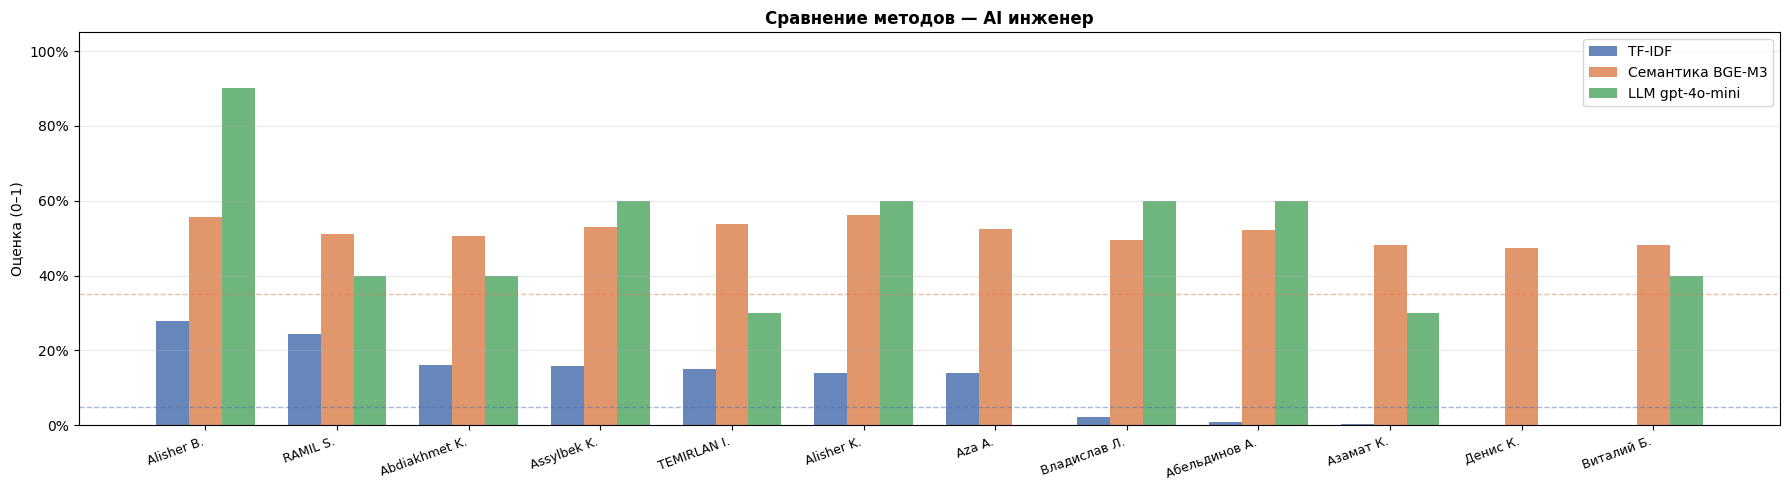

Сохранено: method_comparison.png


In [34]:
tfidf_map    = {item["candidate_id"]: (item.get("tfidf_score") or 0.0, item["candidate"].get("name") or "Неизвестно") for item in tfidf_items}
semantic_map = {item["candidate_id"]: (item.get("semantic_score") or 0.0) for item in semantic_items}
llm_map      = {item["candidate_id"]: (item.get("llm_score") or 0.0) for item in llm_items}

ordered_ids   = [item["candidate_id"] for item in tfidf_items]
ordered_names = [tfidf_map[cid][1] for cid in ordered_ids]
tfidf_vals    = [tfidf_map[cid][0] for cid in ordered_ids]
semantic_vals = [semantic_map.get(cid, 0.0) for cid in ordered_ids]
llm_vals      = [llm_map.get(cid, None) for cid in ordered_ids]

short_names = [n.split()[0] + (" " + n.split()[1][0] + "." if len(n.split()) > 1 else "") for n in ordered_names]

x = np.arange(len(ordered_ids))
width = 0.25

fig, ax = plt.subplots(figsize=(max(10, len(ordered_ids) * 1.5), 5))
ax.bar(x - width, tfidf_vals,    width, label="TF-IDF",         color="#4C72B0", alpha=0.85)
ax.bar(x,          semantic_vals, width, label="Семантика BGE-M3", color="#DD8452", alpha=0.85)

llm_x = [x[i] + width for i, v in enumerate(llm_vals) if v is not None]
llm_y = [v for v in llm_vals if v is not None]
if llm_y:
    ax.bar(llm_x, llm_y, width, label="LLM gpt-4o-mini", color="#55A868", alpha=0.85)

ax.axhline(0.05, color="#4C72B0", linestyle="--", alpha=0.5, linewidth=1)
ax.axhline(0.35, color="#DD8452", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Оценка (0–1)")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title(f"Сравнение методов — {vacancy['title']}", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: method_comparison.png")

In [36]:
TFIDF_THRESHOLD   = 0.05
SEMANTIC_THRESHOLD = 0.35

after_tfidf    = [cid for cid, v in zip(ordered_ids, tfidf_vals)    if v >= TFIDF_THRESHOLD]
after_semantic = [cid for cid in after_tfidf if semantic_map.get(cid, 0.0) >= SEMANTIC_THRESHOLD]
after_llm      = [item["candidate_id"] for item in llm_items][:5]

stages = [len(ordered_ids), len(after_tfidf), len(after_semantic), len(after_llm)]
labels = [
    "Все\nкандидаты",
    f"После TF-IDF\n(≥ {TFIDF_THRESHOLD})",
    f"После семантики\n(≥ {SEMANTIC_THRESHOLD})",
    "После LLM\n(топ-5)",
]

print(f"Этап 0 — все:          {stages[0]}")
print(f"Этап 1 — TF-IDF:       {stages[1]}  ({[tfidf_map[c][1].split()[0] for c in after_tfidf]})")
print(f"Этап 2 — Семантика:    {stages[2]}  ({[tfidf_map[c][1].split()[0] for c in after_semantic]})")
print(f"Этап 3 — LLM топ-5:    {stages[3]}  ({[tfidf_map[c][1].split()[0] for c in after_llm]})")
print(f"\nСэкономлено вызовов LLM: {len(ordered_ids) - len(after_semantic)} из {len(ordered_ids)}")

Этап 0 — все:          12
Этап 1 — TF-IDF:       7  (['Alisher', 'RAMIL', 'Abdiakhmet', 'Assylbek', 'TEMIRLAN', 'Alisher', 'Aza'])
Этап 2 — Семантика:    7  (['Alisher', 'RAMIL', 'Abdiakhmet', 'Assylbek', 'TEMIRLAN', 'Alisher', 'Aza'])
Этап 3 — LLM топ-5:    5  (['Alisher', 'Assylbek', 'Абельдинов', 'Владислав', 'Alisher'])

Сэкономлено вызовов LLM: 5 из 12


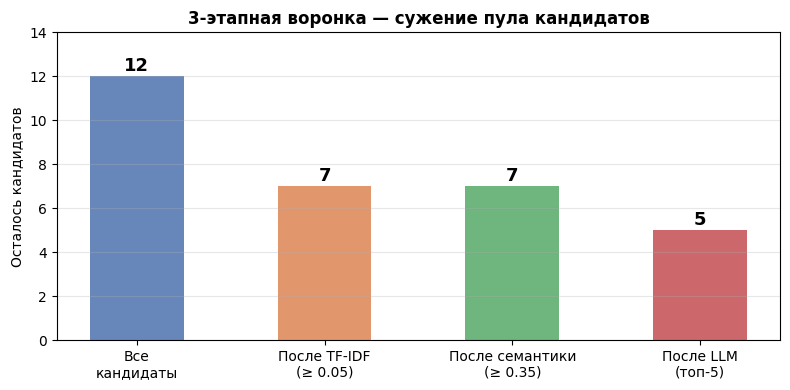

Сохранено: funnel_stages.png


In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = ax.bar(labels, stages, color=colors, alpha=0.85, width=0.5)
for bar, count in zip(bars, stages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(count), ha="center", va="bottom", fontsize=13, fontweight="bold")
ax.set_ylabel("Осталось кандидатов")
ax.set_title("3-этапная воронка — сужение пула кандидатов", fontweight="bold")
ax.set_ylim(0, max(stages) + 2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("funnel_stages.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: funnel_stages.png")

## 7б. Вакансия на русском языке — «Главный специалист управления бизнес-информации»

Те же три метода, но на вакансии, описание которой написано на **русском** языке.


In [38]:
ru_vacancy = vacancies[0]  # Главный специалист управления бизнес-информации
ru_job_id = ru_vacancy["id"]

ru_tfidf_resp    = api("/recommendations/", {"job_id": ru_job_id, "method": "tfidf",    "top_k": top_k_all})
ru_semantic_resp = api("/recommendations/", {"job_id": ru_job_id, "method": "semantic", "top_k": top_k_all})
ru_llm_resp      = api("/recommendations/", {"job_id": ru_job_id, "method": "llm",      "top_k": LLM_TOP_K})

ru_tfidf_map    = {item["candidate_id"]: (item["candidate"].get("name") or "Неизвестно", item.get("tfidf_score") or 0.0)    for item in ru_tfidf_resp["results"]}
ru_semantic_map = {item["candidate_id"]: item.get("semantic_score") or 0.0 for item in ru_semantic_resp["results"]}
ru_llm_map      = {item["candidate_id"]: item.get("llm_score") or 0.0      for item in ru_llm_resp["results"]}

print(f"Вакансия: [{ru_job_id}] {ru_vacancy['title']}\n")
print("TF-IDF:")
for cid, (name, score) in sorted(ru_tfidf_map.items(), key=lambda x: x[1][1], reverse=True):
    print(f"  {name:<35} {score:.4f}")
print("\nLLM:")
for cid in sorted(ru_llm_map, key=ru_llm_map.get, reverse=True):
    print(f"  {ru_tfidf_map[cid][0]:<35} {ru_llm_map[cid]:.2f}")


Вакансия: [39] Главный специалист управления бизнес - информации

TF-IDF:
  Абельдинов Айдар                    0.2162
  Денис Клименко                      0.1673
  Виталий Бурцев                      0.1612
  Азамат Кожаков                      0.1064
  Владислав Литвинов                  0.0972
  Assylbek Khalyk                     0.0162
  RAMIL SALIHAR                       0.0098
  Alisher Kenzhegaliyev               0.0065
  Aza Atzhanova                       0.0063
  Alisher Beisembekov                 0.0056
  TEMIRLAN ILYASOV                    0.0053
  Abdiakhmet Kozhamkulov              0.0048

LLM:
  Абельдинов Айдар                    0.40
  Виталий Бурцев                      0.40
  Abdiakhmet Kozhamkulov              0.30
  Assylbek Khalyk                     0.30
  Alisher Beisembekov                 0.30
  Владислав Литвинов                  0.30
  TEMIRLAN ILYASOV                    0.20
  Азамат Кожаков                      0.20
  RAMIL SALIHAR                     

## 8. Анализ результатов — что показывает сравнение двух вакансий?

### TF-IDF: язык вакансии полностью определяет рейтинг

На AI-вакансии (английский) TF-IDF поставил наверх исключительно кандидатов с англоязычными резюме: Alisher Beisembekov (0.28), RAMIL SALIHAR (0.24), Abdiakhmet, Assylbek, TEMIRLAN. Русскоязычные кандидаты (Виталий Бурцев, Денис Клименко, Азамат) получили ~0%.

На русскоязычной вакансии (раздел 7б) — **зеркальная картина**: наверху оказались Абельдинов, Денис, Виталий, Азамат; те же англоязычные резюме снова получили ~0%.

TF-IDF не оценивает квалификацию — он измеряет лексическое пересечение. При несовпадении языков результат бессмысленен.

---

### Семантика BGE-M3: стабильна, но не чувствительна

На обеих вакансиях все 12 кандидатов оказались в диапазоне 0.47–0.56 — выше порога 0.35, фильтрации не произошло ни разу. На AI-вакансии порядок стал **логичнее** — Alisher Kenzhegaliyev и Alisher Beisembekov (AI/ML-профили) выше, Денис и Виталий ниже — но разброс слишком мал для жёсткого фильтра. Порог 0.35 нужно поднять минимум до 0.50.

---

### LLM gpt-4o-mini: единственный метод с реальной дифференциацией

На AI-вакансии LLM дал разброс 0.30–**0.90**, выявив явного лидера — Alisher Beisembekov с реальным опытом в AI и автоматизации. На русскоязычной вакансии разброс составил 0.20–0.40: меньший разброс отражает реальность — ни один кандидат не имеет прямого опыта в «управлении бизнес-информацией».

---

### Ключевое наблюдение: расхождение TF-IDF и LLM

| Кандидат | TF-IDF (AI вакансия) | LLM (AI вакансия) | Вывод |
|----------|----------------------|--------------------|-------|
| Абельдинов Айдар | ~0% (RU резюме, EN вакансия) | 0.60 | TF-IDF отсеял бы реально подходящего |
| RAMIL SALIHAR | 0.24 (2-е место) | 0.40 (7-е место) | Лексическое совпадение ≠ квалификация |
| TEMIRLAN ILYASOV | 0.15 (5-е место) | 0.30 (9-е место) | Аналогично |

TF-IDF ошибается в обоих направлениях: **занижает** кандидатов с резюме не на том языке и **завышает** тех, у кого просто много общих слов с вакансией. LLM видит реальное соответствие независимо от языка.

---

### Итог

Для многоязычного пула TF-IDF как первый фильтр создаёт ложные отказы. Оптимальная стратегия — использовать его вместе с семантикой по принципу **OR** (проходит, если хотя бы один метод выше порога), либо заменить первый этап семантическим фильтром с повышенным порогом (0.50+).


## 9. Выводы

| | TF-IDF | Семантика (BGE-M3) | LLM (gpt-4o-mini) |
|--|--------|-------------------|-------------------|
| **Скорость** | < 1 мс | ~200 мс (CPU) | ~1–3 с на кандидата |
| **Стоимость** | Бесплатно | Бесплатно (локально) | ~$0.0001–0.001 на кандидата |
| **RU+EN** | Частично | Нативно | Нативно |
| **Объяснение** | Нет | Нет | Полный анализ |
| **Применение** | Первичная фильтрация | Семантическая предфильтрация | Финальное ранжирование |

**Рекомендация для продакшна:** Запускать 3-этапный каскад. TF-IDF сужает с 100 → ~80, семантика с 80 → ~20–30, LLM оценивает эти ~20–30 с объяснениями. Затраты на LLM пропорциональны `O(прошедших_семантику)`, а не `O(всех_кандидатов)`.

**Настройка порогов:** Снизьте порог TF-IDF (например, до 0.02) для более широкого охвата; поднимите порог семантики (например, до 0.50), если все кандидаты кластеризуются выше 0.35.
